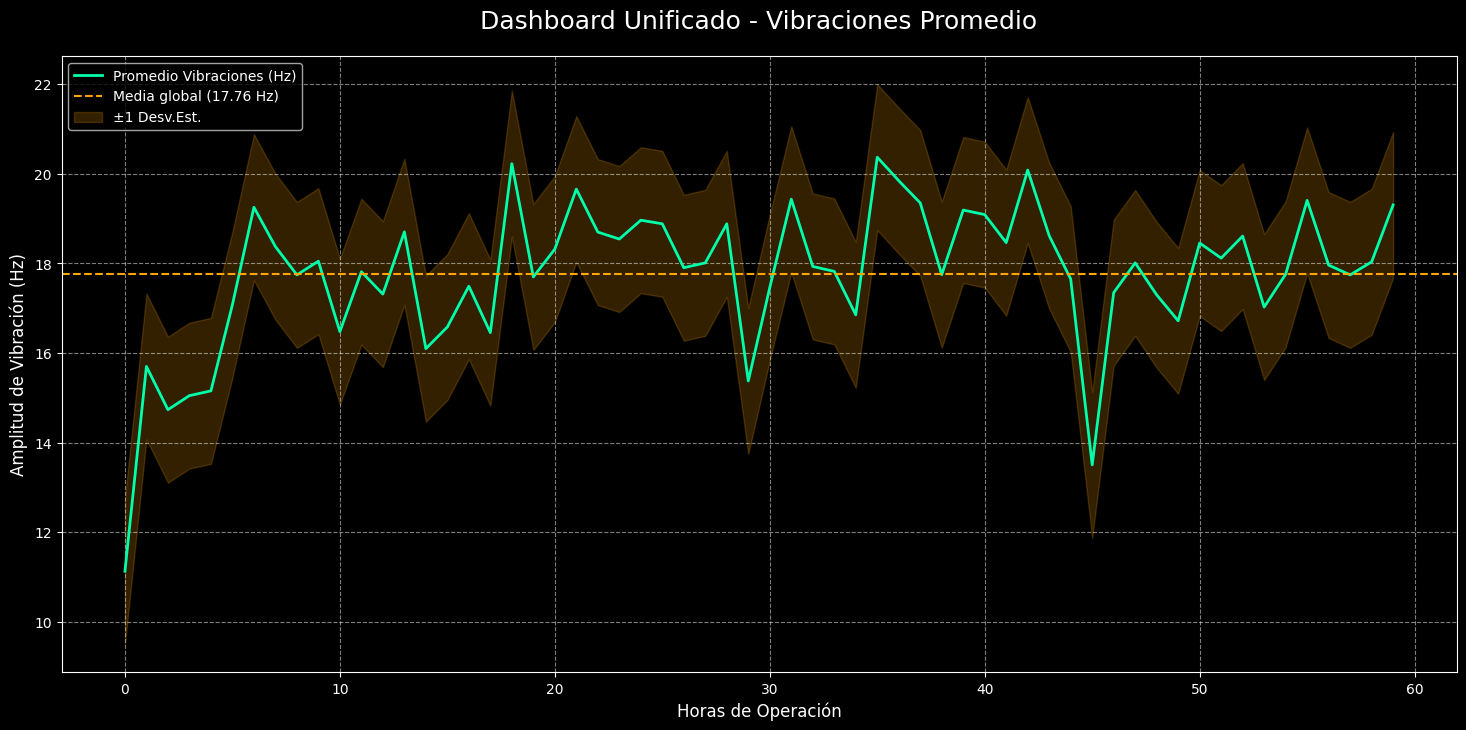

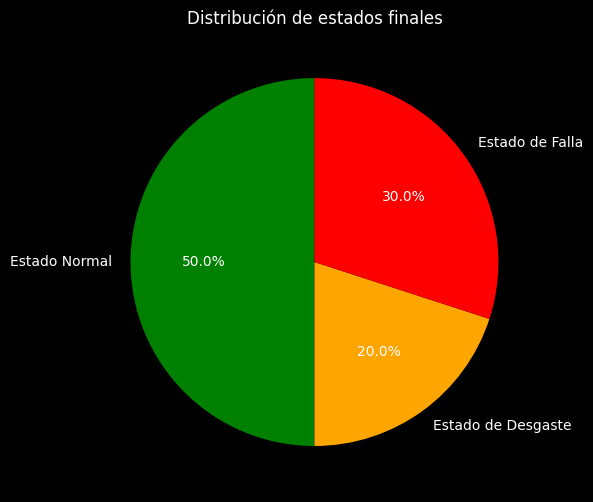

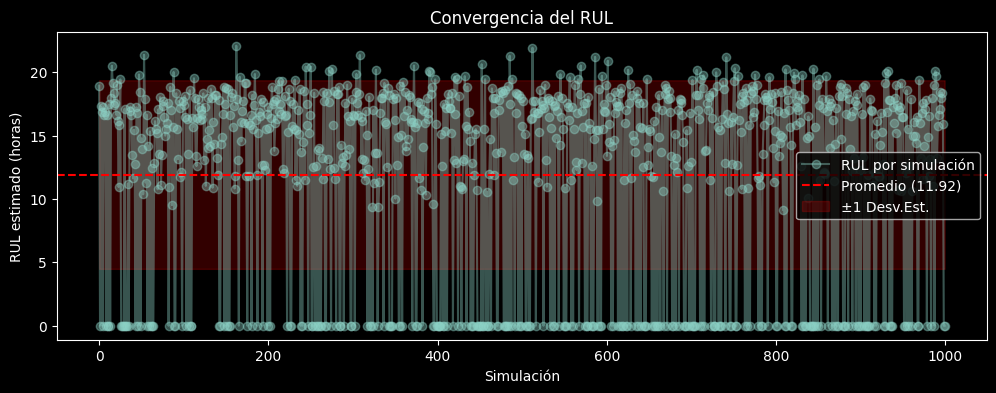

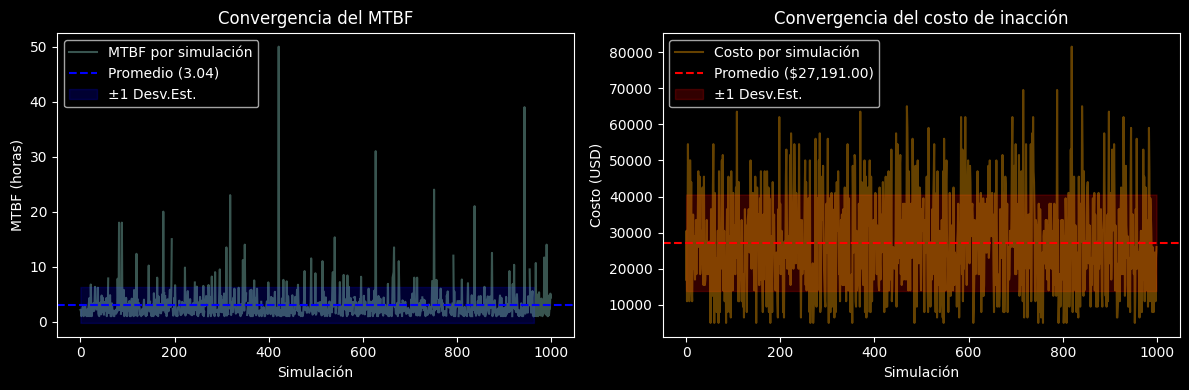


===== Resumen de Convergencia =====
RUL promedio: 11.92 horas
RUL desviación estándar: 7.44 horas
MTBF promedio: 3.04 horas
MTBF desviación estándar: 3.27 horas
Costo promedio de inacción: $27,191.00
Costo desviación estándar: $13,349.96

Distribución de estados:
 - Estado Normal: 54.1%
 - Estado de Desgaste: 21.3%
 - Estado de Falla: 24.7%


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# --- Parámetros de Configuración ---
COSTO_HORA_PARADA = 1500
COSTO_MANTENIMIENTO_PREVENTIVO = 5000

class HMM_PredictiveMaintenance:
    def __init__(self, states, observations, start_prob, transition_matrix, emission_matrix):
        self.states = states
        self.observations = observations
        self.start_prob = start_prob
        self.transition_matrix = transition_matrix
        self.emission_matrix = emission_matrix

        self.state_map = {state: i for i, state in enumerate(states)}
        self.obs_map = {obs: i for i, obs in enumerate(observations)}

        self.state_sequence = []
        self.observation_sequence = []
        self.vibration_hz = []
        self.simulation_steps = 0

    def _generate_vibration_value(self, observation_category):
        if observation_category == 'Vibración Baja':
            return np.random.uniform(1, 10)
        elif observation_category == 'Vibración Media':
            return np.random.uniform(10, 30)
        else:
            return np.random.uniform(30, 60)

    def simulate(self, n_steps):
        self.simulation_steps = n_steps
        current_state_idx = np.random.choice(len(self.states), p=self.start_prob)

        for _ in range(n_steps):
            self.state_sequence.append(self.states[current_state_idx])
            obs_idx = np.random.choice(len(self.observations),
                                       p=self.emission_matrix[current_state_idx, :])
            observation = self.observations[obs_idx]
            self.observation_sequence.append(observation)
            self.vibration_hz.append(self._generate_vibration_value(observation))
            current_state_idx = np.random.choice(len(self.states),
                                                 p=self.transition_matrix[current_state_idx, :])

        #print(f"Simulación de {n_steps} horas completada.")

    def analyze_simulation(self):
        if not self.state_sequence:
            print("Error: No hay datos de simulación. Ejecuta primero simulate().")
            return

        mtbf = self._calculate_mtbf()
        rul = self._estimate_rul()
        maintenance_window = self._find_optimal_maintenance_window()
        cost_no_action = self._calculate_cost_of_inaction()
        recommendations = self._generate_recommendations()
        next_failure_pred = self._predict_next_failure()

        self._generate_health_report(mtbf, rul, maintenance_window,
                                     cost_no_action, recommendations, next_failure_pred)

    def _calculate_mtbf(self):
        failure_hours = [i for i, state in enumerate(self.state_sequence) if state == 'Estado de Falla']
        if len(failure_hours) < 2:
            return float('inf')
        time_between_failures = np.diff(failure_hours)
        return np.mean(time_between_failures) if len(time_between_failures) > 0 else float('inf')

    def _estimate_rul(self):
        if not self.state_sequence:
            return float('inf')

        last_state = self.state_sequence[-1]
        if last_state == 'Estado de Falla':
            return 0

        sim_runs = 100
        time_to_failure = []
        for _ in range(sim_runs):
            current_state_idx = self.state_map[last_state]
            steps = 0
            while self.states[current_state_idx] != 'Estado de Falla' and steps < 200:
                current_state_idx = np.random.choice(len(self.states),
                                                     p=self.transition_matrix[current_state_idx, :])
                steps += 1
            time_to_failure.append(steps)
        return np.mean(time_to_failure)

    def _find_optimal_maintenance_window(self):
        try:
            first_wear_hour = self.state_sequence.index('Estado de Desgaste')
            return f"A partir de la hora {first_wear_hour+1}"
        except ValueError:
            return "No se detectó estado de desgaste en la simulación."

    def _calculate_cost_of_inaction(self):
        hours_in_failure = self.state_sequence.count('Estado de Falla')
        cost = hours_in_failure * COSTO_HORA_PARADA
        hours_in_wear = self.state_sequence.count('Estado de Desgaste')
        if hours_in_wear > 0:
            cost += COSTO_MANTENIMIENTO_PREVENTIVO
        return cost

    def _generate_recommendations(self):
        last_state = self.state_sequence[-1]
        if last_state == 'Estado Normal':
            return "Acción: Continuar monitoreo estándar. No se requiere intervención."
        elif last_state == 'Estado de Desgaste':
            return "Acción: Planificar mantenimiento preventivo. Inspeccionar componentes clave."
        else:
            return "Acción: ¡PARADA INMEDIATA! Realizar mantenimiento correctivo urgente."

    def _predict_next_failure(self):
        rul = self._estimate_rul()
        if rul == 0:
            return "La máquina ya está en estado de falla."
        elif rul > 1000:
            return "No se predice una falla en el futuro cercano."
        return f"Se estima una falla en las próximas {rul:.1f} horas de operación."

    def _generate_health_report(self, mtbf, rul, window, cost, recs, next_fail):
        final_state = self.state_sequence[-1]
        if final_state == 'Estado Normal':
            semaphore = "🟢 SALUD: ÓPTIMA"
        elif final_state == 'Estado de Desgaste':
            semaphore = "🟡 ALERTA: DESGASTE DETECTADO"
        else:
            semaphore = "🔴 PELIGRO: FALLA INMINENTE/ACTUAL"

        report = f"""
=========================================================
        REPORTE DE SALUD DE MAQUINARIA (HMM)
=========================================================
Horas de Operación Simuladas: {self.simulation_steps}

--- DIAGNÓSTICO GENERAL ---
{semaphore}
Estado Actual: {final_state}

--- MÉTRICAS CLAVE DE MANTENIMIENTO ---
- MTBF: {mtbf:.2f} horas
- RUL estimado: {rul:.2f} horas
- Ventana Óptima para Mantenimiento: {window}

--- ANÁLISIS DE RIESGO Y COSTOS ---
- Costo Estimado por Inacción: ${cost:,.2f}
- Predicción de Próxima Falla: {next_fail}

--- RECOMENDACIONES ---
{recs}
=========================================================
        """
        print(report)

    def plot_dashboard(self):
        if not self.state_sequence:
            print("No hay datos para graficar. Ejecuta primero simulate().")
            return

        plt.style.use('dark_background')
        fig, ax = plt.subplots(figsize=(18, 8))
        ax.plot(self.vibration_hz, label='Nivel de Vibración (Hz)', color='#00aaff', linewidth=2)

        state_colors = {'Estado Normal': 'green', 'Estado de Desgaste': 'yellow', 'Estado de Falla': 'red'}
        for i, state in enumerate(self.state_sequence):
            ax.axvspan(i, i + 1, color=state_colors[state], alpha=0.3)

        ax.set_title('Dashboard de Mantenimiento Predictivo', fontsize=18, pad=20)
        ax.set_xlabel('Horas de Operación', fontsize=12)
        ax.set_ylabel('Amplitud de Vibración (Hz)', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.5)

        patches = [mpatches.Patch(color=c, label=s, alpha=0.5) for s, c in state_colors.items()]
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles + patches, loc='upper left')

        plt.tight_layout()
        plt.show()

    @staticmethod
    def simulate_multiple_machines(num_machines, n_steps, states, observations,
                                   start_probabilities, transition_matrix, emission_matrix):
        results = []
        for i in range(num_machines):
            #print(f"\n===== Simulación Máquina {i+1} =====")
            hmm_model = HMM_PredictiveMaintenance(
                states=states,
                observations=observations,
                start_prob=start_probabilities,
                transition_matrix=transition_matrix,
                emission_matrix=emission_matrix
            )
            hmm_model.simulate(n_steps=n_steps)
            #hmm_model.analyze_simulation()
            #hmm_model.plot_dashboard()
            results.append(hmm_model)
        return results




    # --- Nuevo: análisis de convergencia ---
    @staticmethod
    def convergence_analysis(num_runs, n_steps, states, observations,
                             start_probabilities, transition_matrix, emission_matrix):
        rul_values = []
        mtbf_values = []
        cost_values = []
        state_counts = {"Estado Normal":0, "Estado de Desgaste":0, "Estado de Falla":0}

        for _ in range(num_runs):
            hmm_model = HMM_PredictiveMaintenance(
                states=states,
                observations=observations,
                start_prob=start_probabilities,
                transition_matrix=transition_matrix,
                emission_matrix=emission_matrix
            )
            hmm_model.simulate(n_steps=n_steps)
            rul_values.append(hmm_model._estimate_rul())
            mtbf_values.append(hmm_model._calculate_mtbf())
            cost_values.append(hmm_model._calculate_cost_of_inaction())
            for s in hmm_model.state_sequence:
                state_counts[s] += 1

        # Normalizar frecuencias de estados
        total = sum(state_counts.values())
        freqs = {k:v/total for k,v in state_counts.items()}

        # Graficar convergencia de RUL con promedio y desviación
        plt.figure(figsize=(12,4))
        plt.plot(rul_values, marker='o', alpha=0.4, label="RUL por simulación")
        plt.axhline(np.mean(rul_values), color='red', linestyle='--', label=f"Promedio ({np.mean(rul_values):.2f})")
        plt.fill_between(range(len(rul_values)),
                        np.mean(rul_values)-np.std(rul_values),
                        np.mean(rul_values)+np.std(rul_values),
                        color='red', alpha=0.2, label="±1 Desv.Est.")
        plt.title("Convergencia del RUL")
        plt.xlabel("Simulación")
        plt.ylabel("RUL estimado (horas)")
        plt.legend()
        plt.show()

        # Graficar distribución de estados
        #plt.figure(figsize=(6,4))
        #plt.bar(freqs.keys(), freqs.values(), color=['green','orange','red'])
        #plt.title("Distribución de estados en múltiples simulaciones")
        #plt.ylabel("Frecuencia relativa")
        #plt.show()

        # Graficar MTBF y Costos con promedio y desviación
        plt.figure(figsize=(12,4))

        # MTBF
        plt.subplot(1,2,1)
        plt.plot(mtbf_values, alpha=0.4, label="MTBF por simulación")
        mtbf_valid = [v for v in mtbf_values if np.isfinite(v)]
        if mtbf_valid:
            plt.axhline(np.mean(mtbf_valid), color='blue', linestyle='--', label=f"Promedio ({np.mean(mtbf_valid):.2f})")
            plt.fill_between(range(len(mtbf_valid)),
                            np.mean(mtbf_valid)-np.std(mtbf_valid),
                            np.mean(mtbf_valid)+np.std(mtbf_valid),
                            color='blue', alpha=0.2, label="±1 Desv.Est.")
        plt.title("Convergencia del MTBF")
        plt.xlabel("Simulación")
        plt.ylabel("MTBF (horas)")
        plt.legend()

        # Costos
        plt.subplot(1,2,2)
        plt.plot(cost_values, alpha=0.4, color='orange', label="Costo por simulación")
        plt.axhline(np.mean(cost_values), color='red', linestyle='--', label=f"Promedio (${np.mean(cost_values):,.2f})")
        plt.fill_between(range(len(cost_values)),
                        np.mean(cost_values)-np.std(cost_values),
                        np.mean(cost_values)+np.std(cost_values),
                        color='red', alpha=0.2, label="±1 Desv.Est.")
        plt.title("Convergencia del costo de inacción")
        plt.xlabel("Simulación")
        plt.ylabel("Costo (USD)")
        plt.legend()

        plt.tight_layout()
        plt.show()


        return {"RUL": rul_values, "MTBF": mtbf_values, "Costos": cost_values, "Distribución": freqs}

    # --- Nuevo: dashboard unificado ---
    @staticmethod
    def unified_dashboard(results):
        plt.style.use('dark_background')
        fig, ax = plt.subplots(figsize=(18,8))

        # Promedio de vibraciones
        # Promedio de vibraciones
        all_vibrations = [np.array(r.vibration_hz) for r in results]
        min_len = min(len(v) for v in all_vibrations)
        avg_vibrations = np.mean([v[:min_len] for v in all_vibrations], axis=0)

        # Calcular promedio global y desviación estándar
        global_mean = np.mean(avg_vibrations)
        global_std = np.std(avg_vibrations)

        # Graficar curva promedio
        ax.plot(avg_vibrations, label='Promedio Vibraciones (Hz)', color='#00ffaa', linewidth=2)

        # Línea horizontal con el promedio global
        ax.axhline(global_mean, color='orange', linestyle='--',
                  label=f"Media global ({global_mean:.2f} Hz)")

        # Banda sombreada con ±1 desviación estándar
        ax.fill_between(range(len(avg_vibrations)),
                        avg_vibrations - global_std,
                        avg_vibrations + global_std,
                        color='orange', alpha=0.2, label="±1 Desv.Est.")


        # Estados finales de cada máquina
        final_states = [r.state_sequence[-1] for r in results]
        state_colors = {'Estado Normal':'green','Estado de Desgaste':'orange','Estado de Falla':'red'}
        counts = {s:final_states.count(s) for s in state_colors.keys()}

        # Pie chart de estados finales
        fig2, ax2 = plt.subplots(figsize=(6,6))
        ax2.pie(counts.values(), labels=counts.keys(), colors=state_colors.values(),
                autopct='%1.1f%%', startangle=90)
        ax2.set_title("Distribución de estados finales")

        ax.set_title("Dashboard Unificado - Vibraciones Promedio", fontsize=18, pad=20)
        ax.set_xlabel("Horas de Operación", fontsize=12)
        ax.set_ylabel("Amplitud de Vibración (Hz)", fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='upper left')
        plt.tight_layout()
        plt.show()



# --- Configuración y Ejecución ---
if __name__ == "__main__":
    states = ['Estado Normal', 'Estado de Desgaste', 'Estado de Falla']
    observations = ['Vibración Baja', 'Vibración Media', 'Vibración Alta']
    start_probabilities = np.array([0.8, 0.15, 0.05])
    transition_matrix = np.array([
        [0.85, 0.13, 0.02],
        [0.30, 0.50, 0.20],
        [0.05, 0.15, 0.80]
    ])
    emission_matrix = np.array([
        [0.80, 0.15, 0.05],
        [0.30, 0.50, 0.20],
        [0.10, 0.30, 0.60]
    ])

    # Simular varias máquinas
    resultados = HMM_PredictiveMaintenance.simulate_multiple_machines(
        num_machines=100,
        n_steps=60,
        states=states,
        observations=observations,
        start_probabilities=start_probabilities,
        transition_matrix=transition_matrix,
        emission_matrix=emission_matrix
    )

    # Dashboard unificado
    HMM_PredictiveMaintenance.unified_dashboard(resultados)

    # Análisis de convergencia
    convergencia = HMM_PredictiveMaintenance.convergence_analysis(
        num_runs=1000,
        n_steps=60,
        states=states,
        observations=observations,
        start_probabilities=start_probabilities,
        transition_matrix=transition_matrix,
        emission_matrix=emission_matrix
    )


# --- Impresión de resumen numérico ---
print("\n===== Resumen de Convergencia =====")

# RUL
print(f"RUL promedio: {np.mean(convergencia['RUL']):.2f} horas")
print(f"RUL desviación estándar: {np.std(convergencia['RUL']):.2f} horas")

# MTBF (filtrando valores infinitos)
mtbf_valid = [v for v in convergencia['MTBF'] if np.isfinite(v)]
if mtbf_valid:
    print(f"MTBF promedio: {np.mean(mtbf_valid):.2f} horas")
    print(f"MTBF desviación estándar: {np.std(mtbf_valid):.2f} horas")
else:
    print("MTBF: No se pudieron calcular fallas consecutivas en las simulaciones.")

# Costos
print(f"Costo promedio de inacción: ${np.mean(convergencia['Costos']):,.2f}")
print(f"Costo desviación estándar: ${np.std(convergencia['Costos']):,.2f}")

# Distribución de estados
print("\nDistribución de estados:")
for estado, freq in convergencia["Distribución"].items():
    print(f" - {estado}: {freq*100:.1f}%")


